# The Timeseries Quantum Autoencoder - Selected Plots
*TS QAE in Qiskit with angle encoding of TS sliding windows*

By: Jacob Cybulski<br>
Date: August 2023 - February 2024<br>
Aims: The goal of this notebook is to plot the selected data from the results folder

In [1]:
%%html
<style>
table {float:left}
</style>

In [2]:
import sys
sys.path.append('.')
sys.path.append('..')
sys.path

['/home/jacob/Dropbox/Dev/Python/quantum_projects/ts/ts_denoise/qiskit_qae',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python310.zip',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.10',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.10/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.10/site-packages',
 '.',
 '..']

In [3]:
import os
import pylab
import math
import json
import numpy as np

from IPython.display import clear_output

import matplotlib.pyplot as plt
%matplotlib inline

from utils.Target import *
from utils.Window import *
from utils.Callback import *
from utils.TS import *
from utils.Charts import *
from utils.Integrate import *
from utils.Circuits import *
from utils.Angles import *
from utils.Files import *
from utils.Cost import *
from utils.Metrics import *

from matplotlib import set_loglevel
set_loglevel("error")

## Load dataset and (specific) analysis hyper-parameters

In [4]:
# RESULTS_PATH = 'beer_results_v2'
# FIGURES_PATH = 'beer_figures_v2_extra'
# CASE_NAME = 'beer'

### Constants
LOG_NAME = 'beer_qiskit_v5'
CASE_NAME = 'beer_xdf_2'
DATA_NAME = 'beer'
DATA_PATH = f'{LOG_NAME}/data'
TRAIN_PATH = f'{LOG_NAME}/training'
PARAMS_PATH = f'{LOG_NAME}/params'
ANALYSIS_PATH = f'{LOG_NAME}/analysis'
SCORES_PATH = f'{LOG_NAME}/scores'
FIGURES_PATH = f'{LOG_NAME}/figures'

### Show constants
(LOG_NAME, CASE_NAME, DATA_NAME,DATA_PATH, TRAIN_PATH, PARAMS_PATH, ANALYSIS_PATH, SCORES_PATH, FIGURES_PATH)

('beer_qiskit_v5',
 'beer_xdf_2',
 'beer',
 'beer_qiskit_v5/data',
 'beer_qiskit_v5/training',
 'beer_qiskit_v5/params',
 'beer_qiskit_v5/analysis',
 'beer_qiskit_v5/scores',
 'beer_qiskit_v5/figures')

In [5]:
### Load repository info
data_info_path = f'{DATA_PATH}/beer_n160_w8_ws4_z0.03_zr1_info.json'
data_info = read_json_file(data_info_path)
data_info

{'case_name': 'beer',
 'major_version': 3,
 'minor_version': 5,
 'samples': 160,
 'split': 0.75,
 'wind_size': 8,
 'wind_step': 4,
 'horizon': 1,
 'scale': 1,
 'pan': 0,
 'noise': 0.03,
 'noise_reps': 1}

In [6]:
### Load all data hyper-parameters

# Software version
major_version = data_info['major_version']
minor_version = data_info['minor_version']

# Data settings
samples = data_info['samples']
split = data_info['split']
wind_size = data_info['wind_size']
wind_step = data_info['wind_step']
horizon = data_info['horizon']
scale = data_info['scale']
pan = data_info['pan']

# Noise level
noise = data_info['noise']
noise_reps = data_info['noise_reps']

In [7]:
### All created files have the following codes:
#   n: sample size
#   w: window size
#   ws: window step
#   z: level of noise injected
#   zr: replication number of noisy records
DATA_PREF = f'{DATA_NAME}_n{samples}_w{wind_size}_ws{wind_step}_z{noise}_zr{noise_reps}'
DATA_PREF

'beer_n160_w8_ws4_z0.03_zr1'

In [8]:
train_info_default_fpath = f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_info.json'
train_info = read_json_file(train_info_default_fpath)
train_info

{'case_name': 'beer_xdf_2',
 'major_version': 3,
 'minor_version': 5,
 'reps': 2,
 'ent': 'sca',
 'num_qubits': 8,
 'num_trash': 1,
 'num_latent': 7,
 'added_width': 3,
 'cost_type': 'zeroes',
 'cost_yscale': 'linear',
 'shuffle_interv': 20,
 'log_interv': 10,
 'epochs': 2000,
 'shots': 1000,
 'seed': 2024}

In [9]:
reps = train_info['reps']
ent = train_info['ent']
num_qubits = train_info['num_qubits']
num_trash = train_info['num_trash']
num_latent = train_info['num_latent']
added_width = train_info['added_width']
shuffle_interv = train_info['shuffle_interv']
log_interv = train_info['log_interv']
cost_type = train_info['cost_type']
cost_yscale = train_info['cost_yscale']
epochs = train_info['epochs'] 
shots = train_info['shots']
seed = train_info['seed']

In [10]:
### All created files have the following codes:
#   n: sample size
#   w: window size
#   ws: window step
#   z: level of noise injected
#   zr: replication number of noisy records
TRAIN_PREF = f'{CASE_NAME}_n{samples}_w{wind_size}_ws{wind_step}_z{noise}_zr{noise_reps}_reps{reps}_aw{added_width}_{ent}_lat{num_latent}'
TRAIN_PREF

'beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7'

---

## Utilities

## Plotting functions

In [11]:
# ### Plot and compare various performance plots
# #   If log_interv is a number, it applies to all curves
# #   If it is a list, each number applies to its curve
# def multi_perform_plot(pvals, rcParams=(8, 4), yscale='linear', 
#                   backplot=False, smooth_weight=0.9, save_plot=None,
#                   title='Performance vs iteration', meas_type='Cost', 
#                   meas_min=True, labels=[], back_color='linen',
#                   xlim=None, ylim=None, log_interv=1):
#     if not pvals: # Empty list of curves
#         return
#     if type(log_interv) is int:
#         log_int_list = [log_interv]*len(pvals)
#     elif type(log_interv) is list:
#         log_int_list = log_interv
#     else:
#         print('*** log_interv must be an interger or a list')
#         return
#     iter = max([len(p) for p in pvals])*max(log_int_list)
#     plt.rcParams["figure.figsize"] = rcParams
#     plt.title(f'{title} '+('with smoothing ' if smooth_weight>0 else ' ')+
#               f'(iter# {iter})')
#     plt.xlabel(f'Iteration')
#     plt.ylabel(meas_type)
#     if xlim is not None: plt.xlim(xlim)
#     if ylim is not None: plt.ylim(ylim)
#     plt.yscale(yscale)
#     for i in range(len(pvals)):
#         if backplot:
#             plt.plot([x*log_int_list[i] for x in range(len(pvals[i]))], pvals[i], color=back_color)
#     for i in range(len(pvals)):
#         if meas_min:
#             lim = 'min'
#             sel_val = np.round(min(pvals[i]), 3)
#             sel_x = np.argmin(pvals[i])
#         else:
#             lim = 'max'
#             sel_val = np.round(max(pvals[i]), 3)
#             sel_x = np.argmax(pvals[i])
#         smooth_vals = smooth_movtarg(pvals[i], smooth_weight)
#         sel_lab = labels[i] if labels else f'{i}'
#         plt.plot([x*log_int_list[i] for x in range(len(pvals[i]))], smooth_vals, label=f'{sel_lab}  ({lim} {meas_type}={sel_val} @ iter# {sel_x*log_int_list[i]})')
#     plt.legend(loc='best', ncol=1)
#     if save_plot is not None:
#         plt.savefig(save_plot, format='eps')
#     plt.show()



In [12]:
# ### Plot all the selected windows and their recovered data
# def qae_plot_winds(in_org_set, in_meas_set, out_reconstr_set, plot_no=None, ylim=None, save_plot=None, 
#                    title='Original and measured input vs reconstructed data', xlabel="Data points", ylabel="Inter-point differences"):
    
#     sorted_keys = sorted(in_org_set.keys())
#     if plot_no == None:
#         plot_no = len(sorted_keys)
        
#     for sel_wind in sorted_keys:

#         if plot_no == 0:
#             break
    
#         # Retrieve window data
#         print('\n')
#         wind = in_org_set[sel_wind]
#         org_meas = in_meas_set[sel_wind]
#         out_meas = out_reconstr_set[sel_wind]    
        
#         # Plot prepared data
#         plt.rcParams["figure.figsize"] = (12, 6)
#         plt.title(f'{title}, within window {sel_wind}')
#         plt.xlabel(xlabel)
#         plt.ylabel(ylabel)
#         if ylim is not None:
#             plt.ylim(ylim[0], ylim[1])
        
#         # Plot target function
#         plt.plot([x for x in range(len(wind))], wind, color='royalblue', label='Original data')
#         plt.plot([x for x in range(len(wind))], wind, marker='o', color='cornflowerblue', linestyle='None')
#         plt.plot([x for x in range(len(wind))], org_meas, color='darkorange', label='Measured noisy input')
#         plt.plot([x for x in range(len(wind))], org_meas, marker='o', color='orange', linestyle='None')
#         plt.plot([x for x in range(len(wind))], out_meas, color='red', label='Reconstructed data')
#         plt.plot([x for x in range(len(wind))], out_meas, marker='o', color='tomato', linestyle='None')
#         plt.legend(loc='best', ncol=3)
#         if save_plot is not None:
#             plt.savefig(f'{save_plot}_wind{sel_wind}.eps', format='eps')
#         plt.show()

#         plot_no -= 1
        
#     print('\n')

## Sample plots

### Plot all collected data

In [13]:
### All data files

y_train_org_fpath = f'{DATA_PATH}/{DATA_PREF}_y_train_org.arr'
y_valid_org_fpath = f'{DATA_PATH}/{DATA_PREF}_y_valid_org.arr'
y_train_noisy_org_fpath = f'{DATA_PATH}/{DATA_PREF}_y_train_noisy_org.arr'
y_valid_noisy_org_fpath = f'{DATA_PATH}/{DATA_PREF}_y_valid_noisy_org.arr'

y_train_ts_fpath = f'{DATA_PATH}/{DATA_PREF}_y_train_ts.arr'
y_valid_ts_fpath = f'{DATA_PATH}/{DATA_PREF}_y_valid_ts.arr'
y_train_noisy_ts_fpath = f'{DATA_PATH}/{DATA_PREF}_y_train_noisy_ts.arr'
y_valid_noisy_ts_fpath = f'{DATA_PATH}/{DATA_PREF}_y_valid_noisy_ts.arr'

y_train_enc_fpath = f'{DATA_PATH}/{DATA_PREF}_y_train_enc.arr'
y_valid_enc_fpath = f'{DATA_PATH}/{DATA_PREF}_y_valid_enc.arr'
y_train_noisy_enc_fpath = f'{DATA_PATH}/{DATA_PREF}_y_train_noisy_enc.arr'
y_valid_noisy_enc_fpath = f'{DATA_PATH}/{DATA_PREF}_y_valid_noisy_enc.arr'

data_info_fpath = f'{DATA_PATH}/{DATA_PREF}_info.json'
data_info_fpath

'beer_qiskit_v5/data/beer_n160_w8_ws4_z0.03_zr1_info.json'

In [14]:
### Load the necessary data and reshape as necessary

noise_reps = 1

y_train_enc = read_ts_file(y_train_enc_fpath)
y_valid_enc = read_ts_file(y_valid_enc_fpath)

y_train_noisy_enc = read_ts_file(y_train_noisy_enc_fpath).reshape(noise_reps, y_train_enc.shape[0], y_train_enc.shape[1])
y_valid_noisy_enc = read_ts_file(y_valid_noisy_enc_fpath).reshape(noise_reps, y_valid_enc.shape[0], y_valid_enc.shape[1])

y_train_org = read_ts_file(y_train_org_fpath)
y_valid_org = read_ts_file(y_valid_org_fpath)
y_train_noisy_org = read_ts_file(y_train_noisy_org_fpath).reshape(noise_reps, y_train_org.shape[0], y_train_org.shape[1])
y_valid_noisy_org = read_ts_file(y_valid_noisy_org_fpath).reshape(noise_reps, y_valid_org.shape[0], y_valid_org.shape[1])



TS noise = 3.0%, calculated noise in differenced TS = 1.54%, total noise = 3.6188, over the points = 232



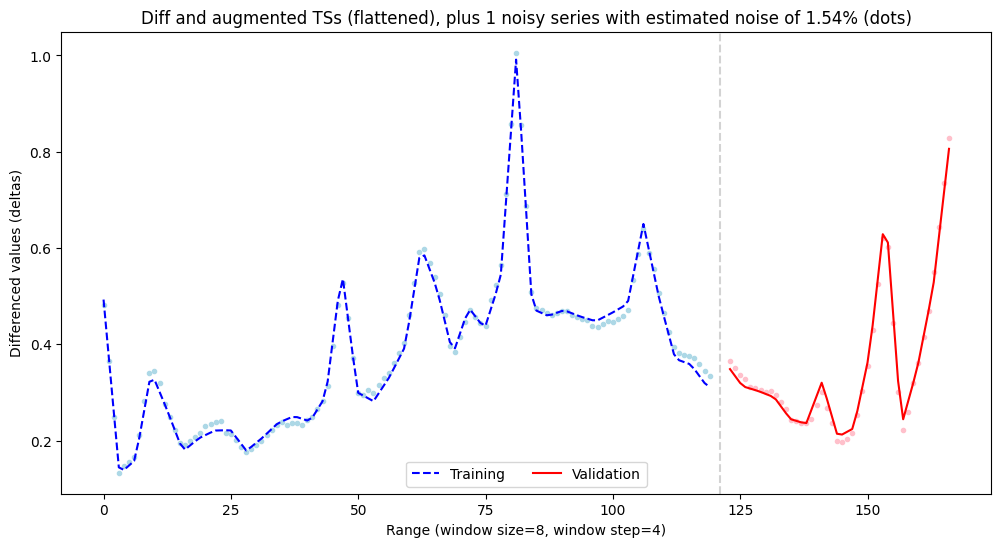

In [15]:
qae_diffaug_plot(y_train_org, y_valid_org, y_train_noisy_org, y_valid_noisy_org, wind_step, noise, noise_reps,
                 xlabel=f'Range (window size={wind_size}, window step={wind_step})',
                 ylabel='Differenced values (deltas)',
                 line_styles={'train_pure':'dashed', 'train_noisy':'none', 'valid_pure':'solid', 'valid_noisy':'none'},
                 # cols = {'train_pure':'black', 'train_noisy':'lightgray', 'valid_pure':'black', 'valid_noisy':'lightgray'},
                 # save_plot=f'{FIGURES_PATH}/{DATA_PREF}_org_with_noise_bw.eps'
                )



TS noise = 3.0%, calculated noise in differenced TS = 5.15%, total noise = 30.087, over the points = 464



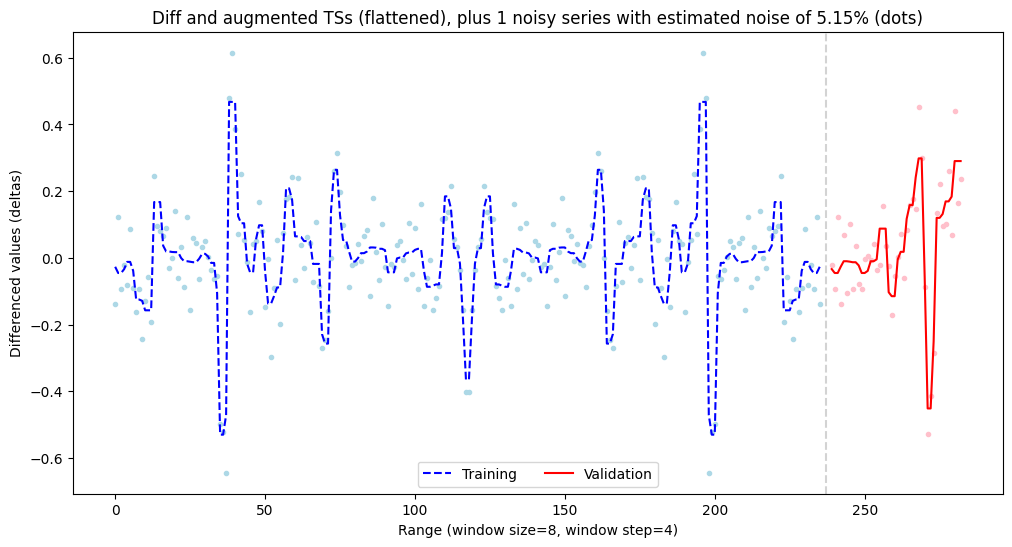

In [16]:
qae_diffaug_plot(y_train_enc, y_valid_enc, y_train_noisy_enc, y_valid_noisy_enc, wind_step, noise, noise_reps,
                 xlabel=f'Range (window size={wind_size}, window step={wind_step})',
                 ylabel='Differenced values (deltas)',
                 line_styles={'train_pure':'dashed', 'train_noisy':'none', 'valid_pure':'solid', 'valid_noisy':'none'},
                 # cols = {'train_pure':'black', 'train_noisy':'lightgray', 'valid_pure':'black', 'valid_noisy':'lightgray'},
                 # save_plot=f'{FIGURES_PATH}/{DATA_PREF}_diff_with_noise_bw.eps'
                )

### Cost and MAE plots
Full-QAE larger beer data set lat=5, trash=3

In [17]:
# Load data
hist = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_hist2000.json')
# tmae = read_json_file(f'{RESULTS_PATH}/qae_wangle_lat5_tr3_reps2_sca_p48_err0.03_zeroes_tmae500_large.json')
# vmae = read_json_file(f'{RESULTS_PATH}/qae_wangle_lat5_tr3_reps2_sca_p48_err0.03_zeroes_vmae500_large.json')

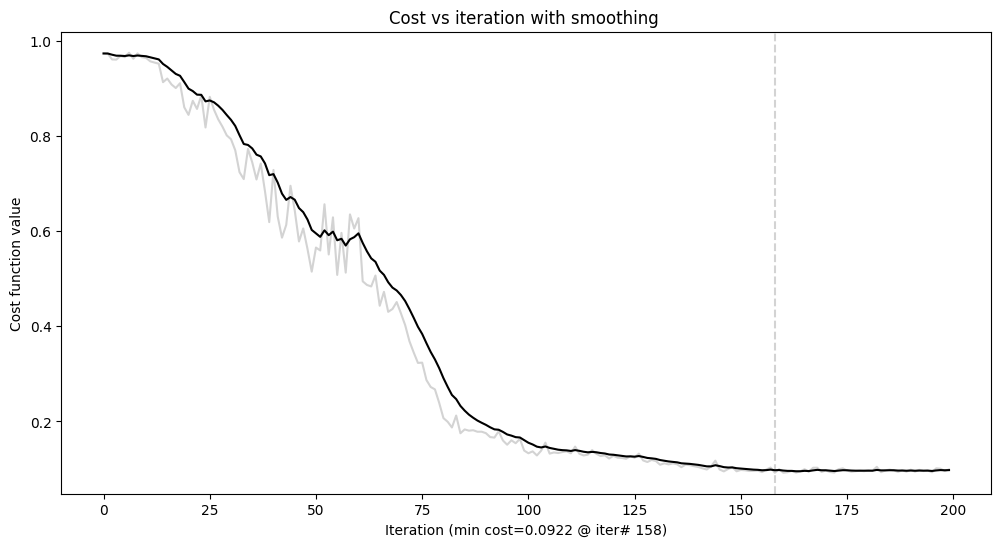

In [18]:
print()
cost_plot(hist, rcParams=(12, 6), smooth_weight=0.8, backplot=True, back_color='lightgray')
          # save_plot=f'{FIGURES_PATH}/qae_{CASE_NAME}_train_perform_cost.eps') # linen aliceblue powderblue paleturquoise whitesmoke lightgray antiquewhite lightsteelblue
print()
# mae_plot(tmae, vmae, rcParams=(12, 6), smooth_weight=0.95, backplot=False, 
#          save_plot=f'{FIGURES_PATH}/train_perform_mae.eps', back_color='lightgray')
# print()

### Comparison of performance for models of different size but the same latent area

In [19]:
# Load data
hist_0_1 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw0_sca_lat7_hist2000.json')
hist_0_2 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw0_sca_lat7_hist2000.json')
hist_0_3 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps3_aw0_sca_lat7_hist2000.json')
hist_1_1 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw1_sca_lat7_hist2000.json')
hist_1_2 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw1_sca_lat7_hist2000.json')
hist_1_3 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps3_aw1_sca_lat7_hist2000.json')
hist_1_4 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps4_aw1_sca_lat7_hist2000.json')
hist_2_1 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw2_sca_lat7_hist2000.json')
hist_2_2 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw2_sca_lat7_hist2000.json')
hist_3_1 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat7_hist2000.json')
hist_3_2 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_hist2000.json')
hist_4_1 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw4_sca_lat7_hist2000.json')
hist_4_2 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw4_sca_lat7_hist2000.json')
hist_5_1 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw5_sca_lat7_hist2000.json')

info_0_1 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw0_sca_lat7_2000/info.json')
info_0_2 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw0_sca_lat7_2000/info.json')
info_0_3 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps3_aw0_sca_lat7_2000/info.json')
info_1_1 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw1_sca_lat7_2000/info.json')
info_1_2 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw1_sca_lat7_2000/info.json')
info_1_3 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps3_aw1_sca_lat7_2000/info.json')
info_1_4 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps4_aw1_sca_lat7_2000/info.json')
info_2_1 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw2_sca_lat7_2000/info.json')
info_2_2 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw2_sca_lat7_2000/info.json')
info_3_1 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat7_2000/info.json')
info_3_2 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_2000/info.json')
info_4_1 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw4_sca_lat7_2000/info.json')
info_4_2 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw4_sca_lat7_2000/info.json')
info_5_1 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw5_sca_lat7_2000/info.json')


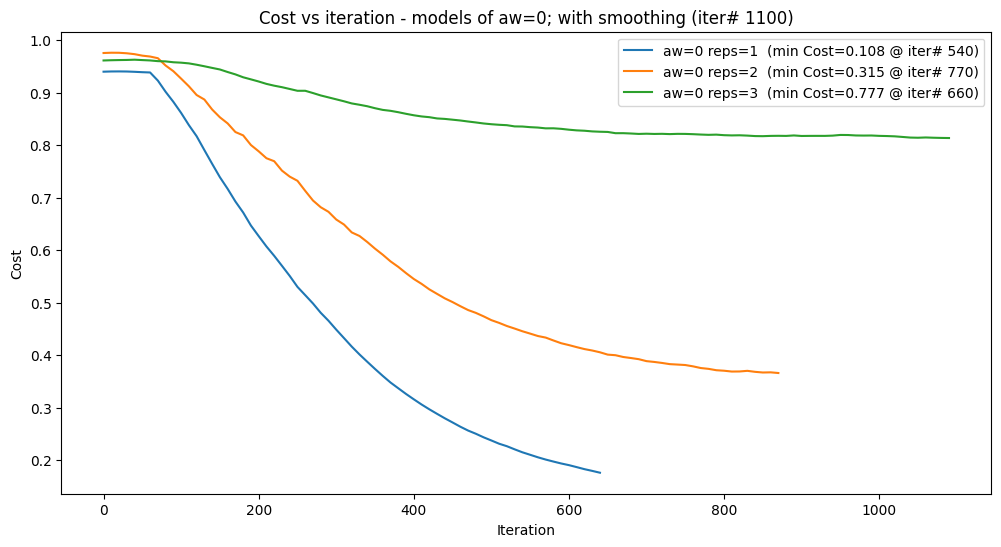

In [20]:
hist_data = [hist_0_1, hist_0_2, hist_0_3]
labels = ['aw=0 reps=1', 'aw=0 reps=2', 'aw=0 reps=3']
log_ints = [info_0_1['log_interv'], info_0_2['log_interv'], info_0_3['log_interv']]

multi_perform_plot(hist_data, rcParams=(12, 6), yscale='linear', # yscale='log'
                  backplot=False, smooth_weight=0.95, log_interv=log_ints,
                  title='Cost vs iteration - models of aw=0;', 
                  meas_type='Cost', meas_min=True, labels=labels, back_color='lightgray',
                  # save_plot=f'{FIGURES_PATH}/qae_{CASE_NAME}_train_perform_cost_reps1_4.eps',
                  ) # 'linen' 'aliceblue' 'powderblue' 'paleturquoise' 'whitesmoke' 'lightgray' 'antiquewhite'

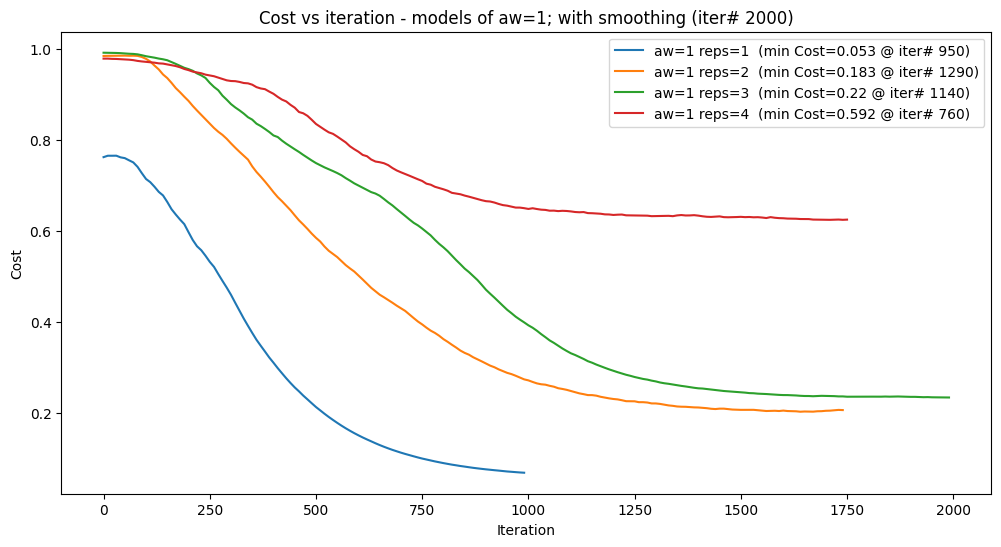

In [21]:
hist_data = [hist_1_1, hist_1_2, hist_1_3, hist_1_4]
labels = ['aw=1 reps=1', 'aw=1 reps=2', 'aw=1 reps=3', 'aw=1 reps=4']
log_ints = [info_1_1['log_interv'], info_1_2['log_interv'], info_1_3['log_interv'], info_1_4['log_interv']]

multi_perform_plot(hist_data, rcParams=(12, 6), yscale='linear', # yscale='log'
                  backplot=False, smooth_weight=0.95, log_interv=log_ints,
                  title='Cost vs iteration - models of aw=1;', 
                  meas_type='Cost', meas_min=True, labels=labels, back_color='lightgray',
                  # save_plot=f'{FIGURES_PATH}/qae_{CASE_NAME}_train_perform_cost_reps1_4.eps',
                  ) # 'linen' 'aliceblue' 'powderblue' 'paleturquoise' 'whitesmoke' 'lightgray' 'antiquewhite'

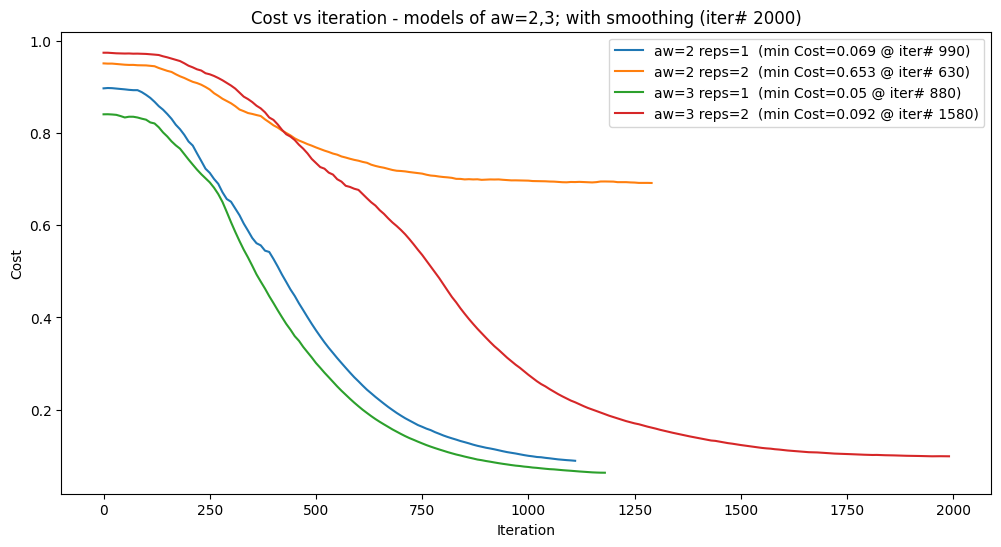

In [22]:
hist_data = [hist_2_1, hist_2_2, hist_3_1, hist_3_2]
labels = ['aw=2 reps=1', 'aw=2 reps=2', 'aw=3 reps=1', 'aw=3 reps=2']
log_ints = [info_2_1['log_interv'], info_2_2['log_interv'], info_3_1['log_interv'], info_3_2['log_interv']]

multi_perform_plot(hist_data, rcParams=(12, 6), yscale='linear', # yscale='log'
                  backplot=False, smooth_weight=0.95, log_interv=log_ints,
                  title='Cost vs iteration - models of aw=2,3;', 
                  meas_type='Cost', meas_min=True, labels=labels, back_color='lightgray',
                  # save_plot=f'{FIGURES_PATH}/qae_{CASE_NAME}_train_perform_cost_reps1_4.eps',
                  ) # 'linen' 'aliceblue' 'powderblue' 'paleturquoise' 'whitesmoke' 'lightgray' 'antiquewhite'

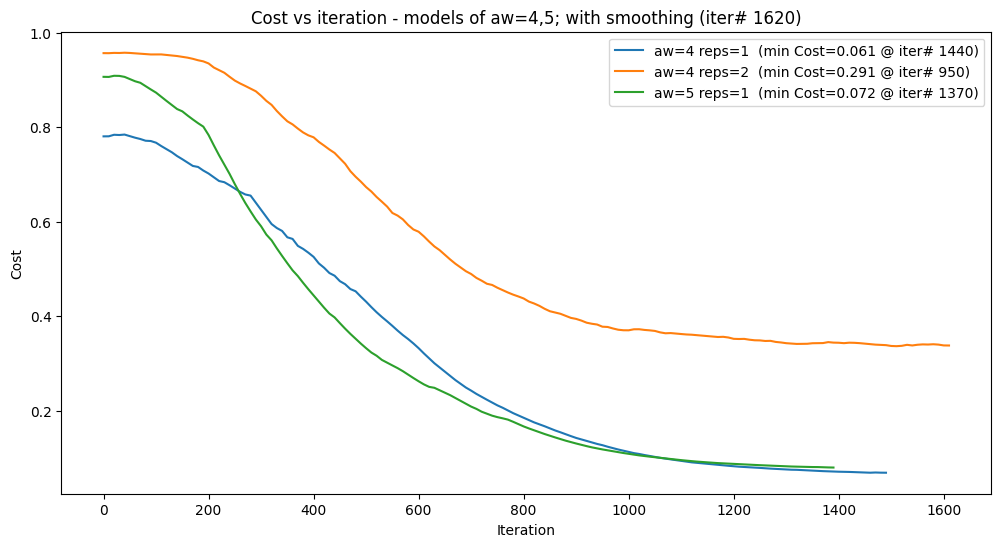

In [23]:
hist_data = [hist_4_1, hist_4_2, hist_5_1]
labels = ['aw=4 reps=1', 'aw=4 reps=2', 'aw=5 reps=1']
log_ints = [info_4_1['log_interv'], info_4_2['log_interv'], info_5_1['log_interv']]

multi_perform_plot(hist_data, rcParams=(12, 6), yscale='linear', # yscale='log'
                  backplot=False, smooth_weight=0.95, log_interv=log_ints,
                  title='Cost vs iteration - models of aw=4,5;', 
                  meas_type='Cost', meas_min=True, labels=labels, back_color='lightgray',
                  # save_plot=f'{FIGURES_PATH}/qae_{CASE_NAME}_train_perform_cost_reps1_4.eps',
                  ) # 'linen' 'aliceblue' 'powderblue' 'paleturquoise' 'whitesmoke' 'lightgray' 'antiquewhite'

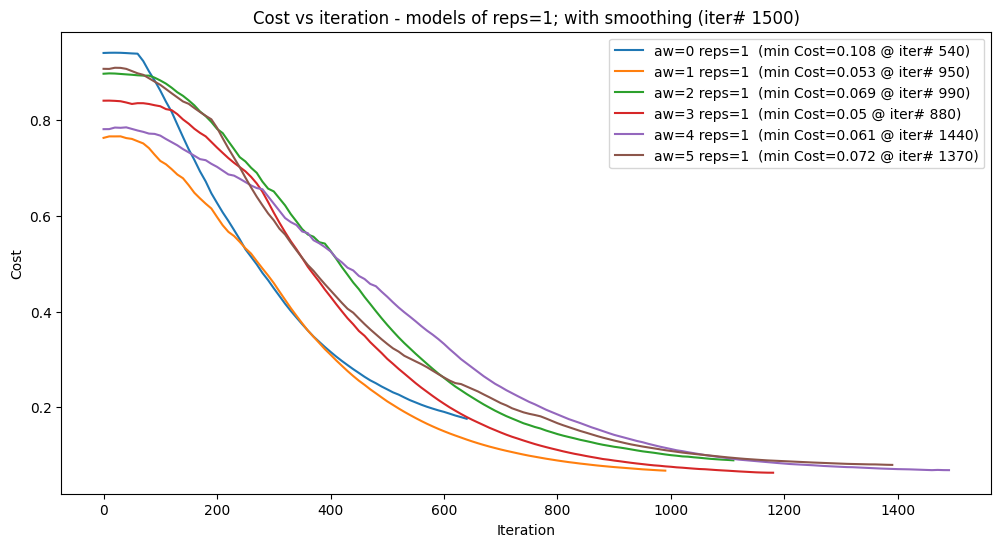

In [24]:
hist_data = [hist_0_1, hist_1_1, hist_2_1, hist_3_1, hist_4_1, hist_5_1]
labels = ['aw=0 reps=1', 'aw=1 reps=1', 'aw=2 reps=1', 'aw=3 reps=1', 'aw=4 reps=1', 'aw=5 reps=1']
log_ints = [info_0_1['log_interv'], info_1_1['log_interv'], info_2_1['log_interv'], info_3_1['log_interv'], info_4_1['log_interv'], info_5_1['log_interv']]

multi_perform_plot(hist_data, rcParams=(12, 6), yscale='linear', # yscale='log'
                  backplot=False, smooth_weight=0.95, log_interv=log_ints,
                  title='Cost vs iteration - models of reps=1;', 
                  meas_type='Cost', meas_min=True, labels=labels, back_color='lightgray',
                  # save_plot=f'{FIGURES_PATH}/qae_{CASE_NAME}_train_perform_cost_reps1_4.eps',
                  ) # 'linen' 'aliceblue' 'powderblue' 'paleturquoise' 'whitesmoke' 'lightgray' 'antiquewhite'

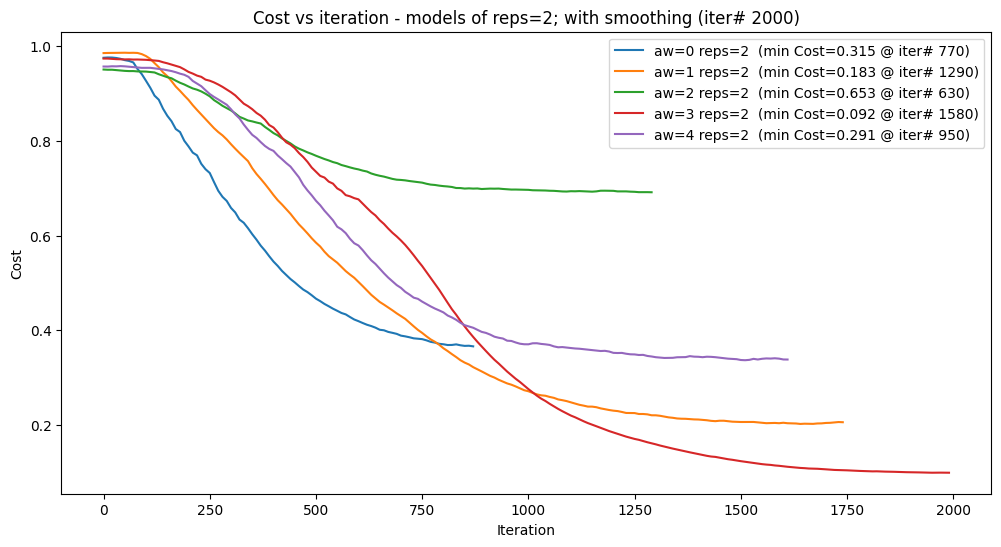

In [25]:
hist_data = [hist_0_2, hist_1_2, hist_2_2, hist_3_2, hist_4_2]
labels = ['aw=0 reps=2', 'aw=1 reps=2', 'aw=2 reps=2', 'aw=3 reps=2', 'aw=4 reps=2']
log_ints = [info_0_2['log_interv'], info_1_2['log_interv'], info_2_2['log_interv'], info_3_2['log_interv'], info_4_2['log_interv']]

multi_perform_plot(hist_data, rcParams=(12, 6), yscale='linear', # yscale='log'
                  backplot=False, smooth_weight=0.95, log_interv=log_ints,
                  title='Cost vs iteration - models of reps=2;', 
                  meas_type='Cost', meas_min=True, labels=labels, back_color='lightgray',
                  # save_plot=f'{FIGURES_PATH}/qae_{CASE_NAME}_train_perform_cost_reps1_4.eps',
                  ) # 'linen' 'aliceblue' 'powderblue' 'paleturquoise' 'whitesmoke' 'lightgray' 'antiquewhite'

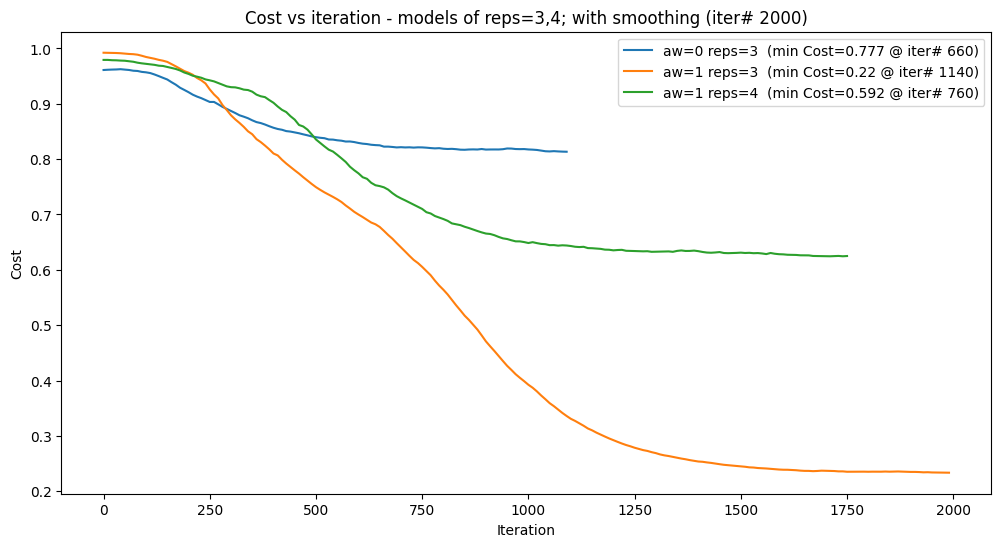

In [26]:
hist_data = [hist_0_3, hist_1_3, hist_1_4]
labels = ['aw=0 reps=3', 'aw=1 reps=3', 'aw=1 reps=4']
log_ints = [info_0_3['log_interv'], info_1_3['log_interv'], info_1_4['log_interv']]

multi_perform_plot(hist_data, rcParams=(12, 6), yscale='linear', # yscale='log'
                  backplot=False, smooth_weight=0.95, log_interv=log_ints,
                  title='Cost vs iteration - models of reps=3,4;', 
                  meas_type='Cost', meas_min=True, labels=labels, back_color='lightgray',
                  # save_plot=f'{FIGURES_PATH}/qae_{CASE_NAME}_train_perform_cost_reps1_4.eps',
                  ) # 'linen' 'aliceblue' 'powderblue' 'paleturquoise' 'whitesmoke' 'lightgray' 'antiquewhite'

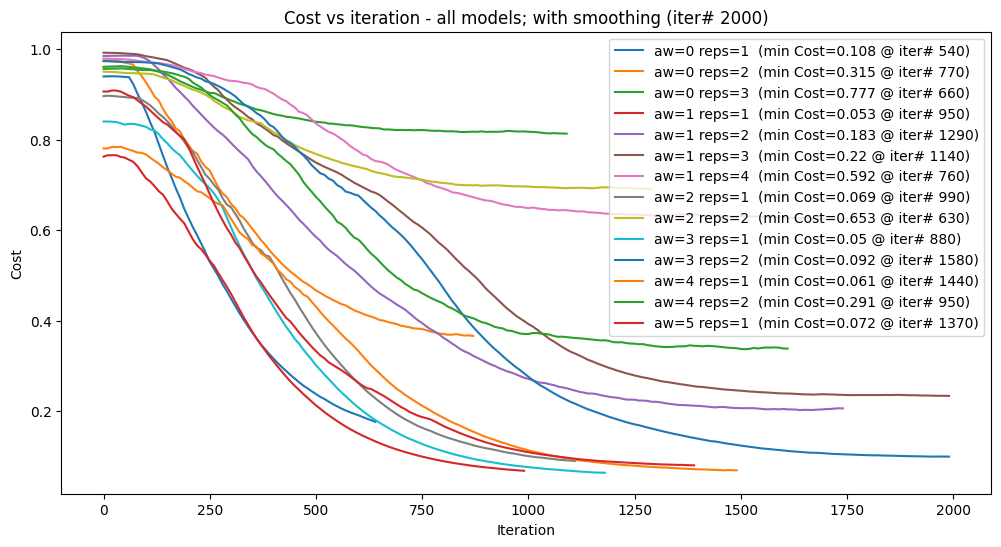

In [27]:
hist_data = [hist_0_1, hist_0_2, hist_0_3]+ \
            [hist_1_1, hist_1_2, hist_1_3, hist_1_4]+ \
            [hist_2_1, hist_2_2, hist_3_1, hist_3_2]+ \
            [hist_4_1, hist_4_2, hist_5_1]
labels =    ['aw=0 reps=1', 'aw=0 reps=2', 'aw=0 reps=3']+ \
            ['aw=1 reps=1', 'aw=1 reps=2', 'aw=1 reps=3', 'aw=1 reps=4']+ \
            ['aw=2 reps=1', 'aw=2 reps=2', 'aw=3 reps=1', 'aw=3 reps=2']+ \
            ['aw=4 reps=1', 'aw=4 reps=2', 'aw=5 reps=1']
log_ints =  [info_0_1['log_interv'], info_0_2['log_interv'], info_0_3['log_interv']]+ \
            [info_1_1['log_interv'], info_1_2['log_interv'], info_1_3['log_interv'], info_1_4['log_interv']]+ \
            [info_2_1['log_interv'], info_2_2['log_interv'], info_3_1['log_interv'], info_3_2['log_interv']]+ \
            [info_4_1['log_interv'], info_4_2['log_interv'], info_5_1['log_interv']]

multi_perform_plot(hist_data, rcParams=(12, 6), yscale='linear', # yscale='log'
                  backplot=False, smooth_weight=0.95, log_interv=log_ints,
                  title='Cost vs iteration - all models;', 
                  meas_type='Cost', meas_min=True, labels=labels, back_color='lightgray',
                  # save_plot=f'{FIGURES_PATH}/qae_{CASE_NAME}_train_perform_cost_reps1_4.eps',
                  ) # 'linen' 'aliceblue' 'powderblue' 'paleturquoise' 'whitesmoke' 'lightgray' 'antiquewhite'

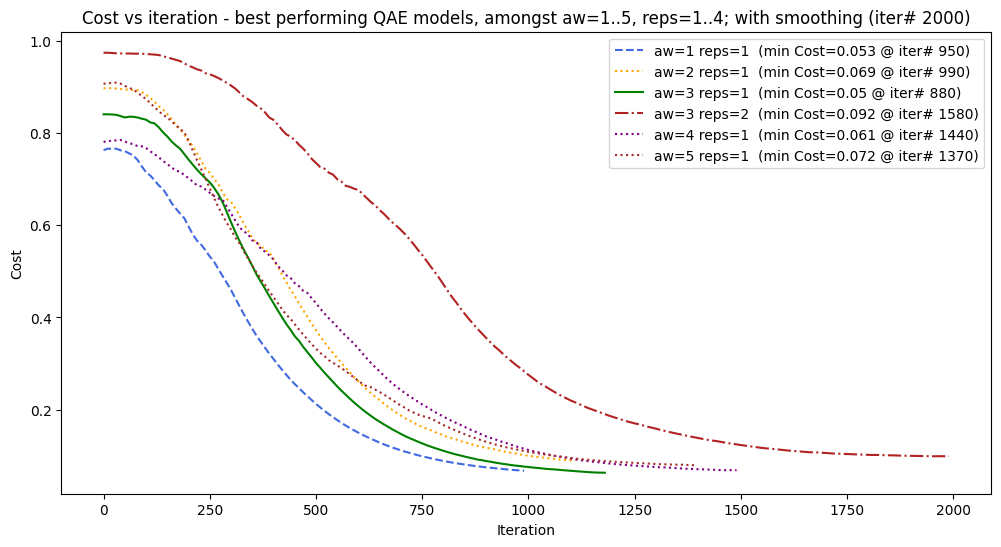

In [28]:
hist_data = [hist_1_1, hist_2_1, hist_3_1, hist_3_2, hist_4_1, hist_5_1]
labels = ['aw=1 reps=1', 'aw=2 reps=1', 'aw=3 reps=1', 'aw=3 reps=2', 'aw=4 reps=1', 'aw=5 reps=1']
log_ints = [info_1_1['log_interv'], info_2_1['log_interv'], info_3_1['log_interv'], info_3_2['log_interv'], info_4_1['log_interv'], info_5_1['log_interv']]

multi_perform_plot(hist_data, rcParams=(12, 6), yscale='linear', # yscale='log'
                    backplot=False, smooth_weight=0.95, log_interv=log_ints,
                    title='Cost vs iteration - best performing QAE models, amongst aw=1..5, reps=1..4;', 
                    meas_type='Cost', meas_min=True, labels=labels, back_color='lightgray',
                    line_styles=['dashed', 'dotted', 'solid', 'dashdot', 'dotted', 'dotted'],
                    # line_cols=['black', 'gray', 'black', 'black', 'gray', 'gray'],
                    # line_styles=['solid', 'solid', 'solid', 'solid', 'solid', 'solid'], 
                    line_cols=['royalblue', 'orange', 'green', 'firebrick', 'purple', 'brown'],
                    # save_plot=f'{FIGURES_PATH}/{DATA_PREF}_train_perform_cost_aw1_5_reps1_2_bw.eps',
                  ) # 'linen' 'aliceblue' 'powderblue' 'paleturquoise' 'whitesmoke' 'lightgray' 'antiquewhite'

### Comparison of performance for models of different latent space but the same size (weight and depth)

In [29]:
# Load data
mae_3_1_1 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat1_hist2000.json')
mae_3_1_2 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat2_hist2000.json')
mae_3_1_3 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat3_hist2000.json')
mae_3_1_4 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat4_hist2000.json')
mae_3_1_5 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat5_hist2000.json')
mae_3_1_6 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat6_hist2000.json')
mae_3_1_7 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat7_hist2000.json')
mae_3_1_8 = read_json_file(f'{TRAIN_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat8_hist2000.json')

info_3_1_1 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat1_2000/info.json')
info_3_1_2 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat2_2000/info.json')
info_3_1_3 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat3_2000/info.json')
info_3_1_4 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat4_2000/info.json')
info_3_1_5 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat5_2000/info.json')
info_3_1_6 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat6_2000/info.json')
info_3_1_7 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat7_2000/info.json')
info_3_1_8 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps1_aw3_sca_lat8_2000/info.json')

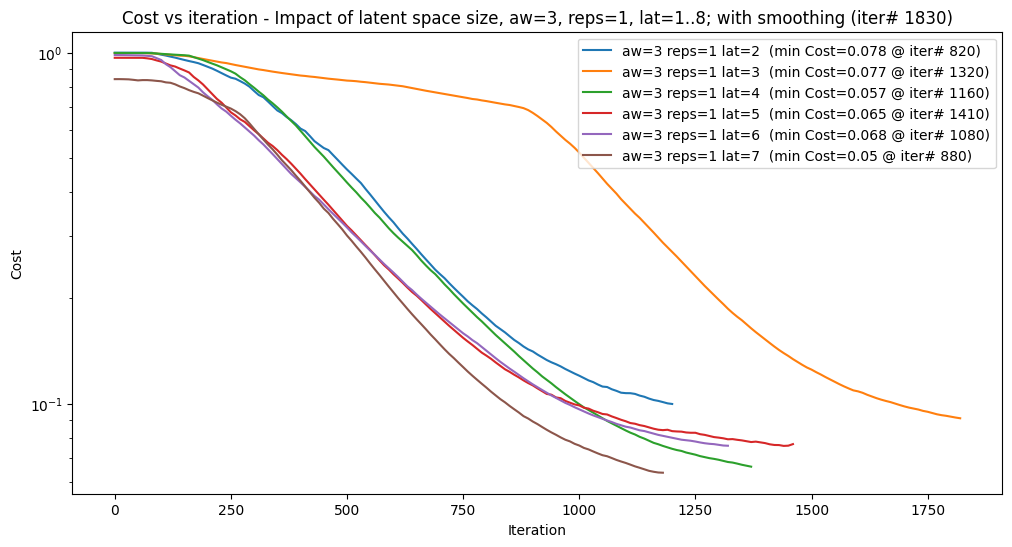

In [30]:
# mae_data = [mae_3_1_1, mae_3_1_2, mae_3_1_3, mae_3_1_4, mae_3_1_5, mae_3_1_6, mae_3_1_7, mae_3_1_8]
# labels = ['aw=1 reps=1 lat=1', 'aw=1 reps=1 lat=2', 'aw=1 reps=1 lat=3', 'aw=1 reps=1 lat=4', 'aw=1 reps=1 lat=5', 'aw=1 reps=1 lat=6', 'aw=1 reps=1 lat=7', 'aw=1 reps=1 lat=8']
# log_ints = [info_3_1_1['log_interv'], info_3_1_2['log_interv'], info_3_1_3['log_interv'], info_3_1_4['log_interv'], info_3_1_5['log_interv'], info_3_1_6['log_interv'], info_3_1_7['log_interv'], info_3_1_8['log_interv']]
mae_data = [mae_3_1_2, mae_3_1_3, mae_3_1_4, mae_3_1_5, mae_3_1_6, mae_3_1_7]
labels = ['aw=3 reps=1 lat=2', 'aw=3 reps=1 lat=3', 'aw=3 reps=1 lat=4', 'aw=3 reps=1 lat=5', 'aw=3 reps=1 lat=6', 'aw=3 reps=1 lat=7']
log_ints = [info_3_1_2['log_interv'], info_3_1_3['log_interv'], info_3_1_4['log_interv'], info_3_1_5['log_interv'], info_3_1_6['log_interv'], info_3_1_7['log_interv']]

multi_perform_plot(mae_data, rcParams=(12, 6), yscale='log', # yscale='linear'
                  backplot=False, smooth_weight=0.95, log_interv=log_ints,
                  title='Cost vs iteration - Impact of latent space size, aw=3, reps=1, lat=1..8;', 
                  meas_type='Cost', meas_min=True, labels=labels, back_color='lightgray',
                  # save_plot=f'{FIGURES_PATH}/{DATA_PREF}_train_perform_cost_aw3_reps1_lat1_8.eps',
                  ) # 'linen' 'aliceblue' 'powderblue' 'paleturquoise' 'whitesmoke' 'lightgray' 'antiquewhite'

In [31]:
# Load data
mae_3_2_1 = read_ts_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat1_2000/hist_vmae.arr')
mae_3_2_2 = read_ts_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat2_2000/hist_vmae.arr')
mae_3_2_3 = read_ts_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat3_2000/hist_vmae.arr')
mae_3_2_4 = read_ts_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat4_2000/hist_vmae.arr')
mae_3_2_5 = read_ts_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat5_2000/hist_vmae.arr')
mae_3_2_6 = read_ts_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat6_2000/hist_vmae.arr')
mae_3_2_7 = read_ts_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_2000/hist_vmae.arr')
mae_3_2_8 = read_ts_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat8_2000/hist_vmae.arr')

info_3_2_1 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat1_2000/info.json')
info_3_2_2 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat2_2000/info.json')
info_3_2_3 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat3_2000/info.json')
info_3_2_4 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat4_2000/info.json')
info_3_2_5 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat5_2000/info.json')
info_3_2_6 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat6_2000/info.json')
info_3_2_7 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_2000/info.json')
info_3_2_8 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat8_2000/info.json')

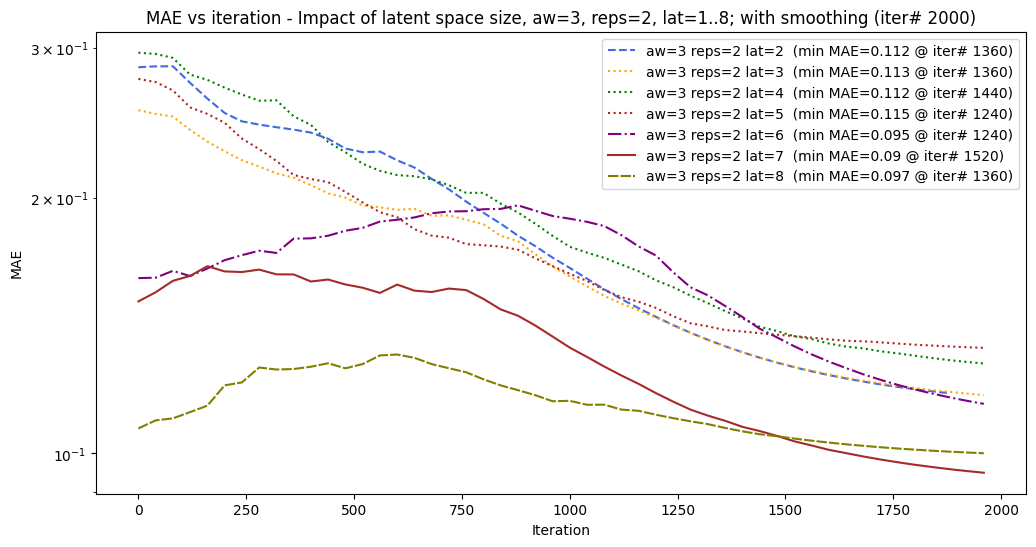

In [32]:
# mae_data = [mae_3_2_1, mae_3_2_2, mae_3_2_3, mae_3_2_4, mae_3_2_5, mae_3_2_6, mae_3_2_7, mae_3_2_8]
# labels = ['aw=1 reps=1 lat=1', 'aw=1 reps=1 lat=2', 'aw=1 reps=1 lat=3', 'aw=1 reps=1 lat=4', 'aw=1 reps=1 lat=5', 'aw=1 reps=1 lat=6', 'aw=1 reps=1 lat=7', 'aw=1 reps=1 lat=8']
# log_ints = [info_3_2_1['log_interv'], info_3_2_2['log_interv'], info_3_2_3['log_interv'], info_3_2_4['log_interv'], info_3_2_5['log_interv'], info_3_2_6['log_interv'], info_3_2_7['log_interv'], info_3_1_8['log_interv']]
mae_data = [mae_3_2_2, mae_3_2_3, mae_3_2_4, mae_3_2_5, mae_3_2_6, mae_3_2_7, mae_3_2_8]
labels = ['aw=3 reps=2 lat=2', 'aw=3 reps=2 lat=3', 'aw=3 reps=2 lat=4', 'aw=3 reps=2 lat=5', 'aw=3 reps=2 lat=6', 'aw=3 reps=2 lat=7', 'aw=3 reps=2 lat=8']
log_ints = [info_3_2_2['log_interv']*info_3_2_2['loss_interv'], info_3_2_3['log_interv']*info_3_2_3['loss_interv'], 
            info_3_2_4['log_interv']*info_3_2_4['loss_interv'], info_3_2_5['log_interv']*info_3_2_5['loss_interv'], 
            info_3_2_6['log_interv']*info_3_2_6['loss_interv'], info_3_2_7['log_interv']*info_3_2_7['loss_interv'], 
            info_3_2_8['log_interv']*info_3_2_8['loss_interv']]

multi_perform_plot(mae_data, rcParams=(12, 6), yscale='log', # yscale='linear'/'log', 
                    backplot=False, smooth_weight=0.9, log_interv=log_ints,
                    title='MAE vs iteration - Impact of latent space size, aw=3, reps=2, lat=1..8;', 
                    meas_type='MAE', meas_min=True, labels=labels, back_color='lightgray',
                    line_styles=['dashed', 'dotted', 'dotted', 'dotted', 'dashdot', 'solid', (0, (5, 1))],
                    # line_cols=['black', 'gray', 'gray', 'gray', 'black', 'black', 'gray'],
                    # line_styles=['solid', 'solid', 'solid', 'solid', 'solid', 'solid', 'solid'], 
                    line_cols=['royalblue', 'orange', 'green', 'firebrick', 'purple', 'brown', 'olive'],
                    # save_plot=f'{FIGURES_PATH}/{DATA_PREF}_train_perform_mae_aw3_reps2_lat1_8_bw.eps',
                  ) # 'linen' 'aliceblue' 'powderblue' 'paleturquoise' 'whitesmoke' 'lightgray' 'antiquewhite'

### Training vs. Validation

In [33]:
train_mae_3_2_7 = read_ts_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_2000/hist_tmae.arr')
valid_mae_3_2_7 = read_ts_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_2000/hist_vmae.arr')
info_3_2_7 = read_json_file(f'{ANALYSIS_PATH}/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_2000/info.json')

In [34]:
mae_data = [train_mae_3_2_7, valid_mae_3_2_7]
labels = ['Training', 'Validation']
log_ints = [info_3_2_7['log_interv']*info_3_2_7['loss_interv'], info_3_2_7['log_interv']*info_3_2_7['loss_interv']]

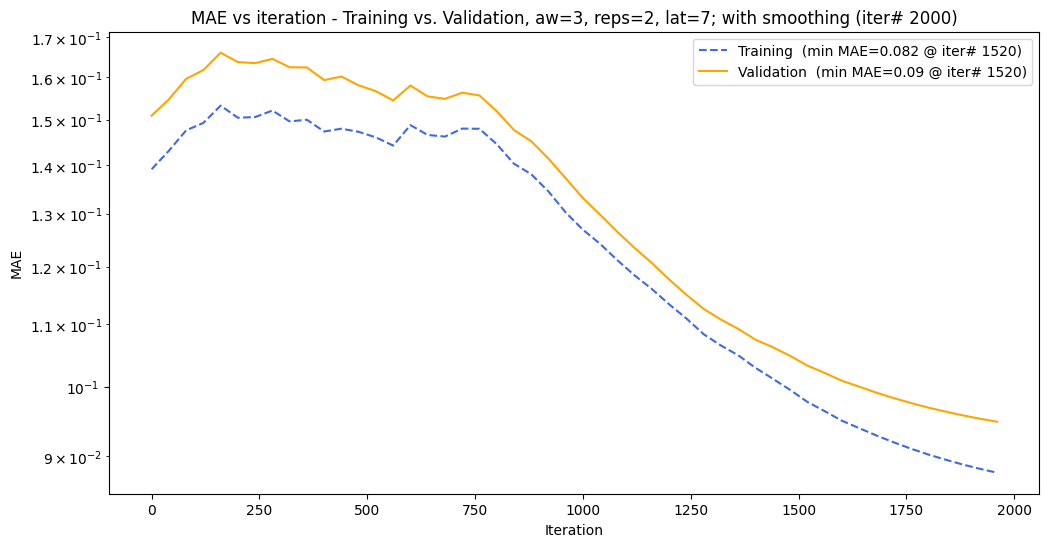

In [35]:
multi_perform_plot(mae_data, rcParams=(12, 6), yscale='log', # yscale='linear'/'log', 
                    backplot=False, smooth_weight=0.9, log_interv=log_ints,
                    title='MAE vs iteration - Training vs. Validation, aw=3, reps=2, lat=7;', 
                    meas_type='MAE', meas_min=True, labels=labels, back_color='lightgray',
                    line_styles=['dashed', 'solid', 'solid', 'solid', 'solid'],
                    # line_cols=['black', 'black', 'black', 'black', 'black'],
                    # line_styles=['solid', 'solid', 'solid', 'solid', 'solid', 'solid'], 
                    line_cols=['royalblue', 'orange', 'green', 'firebrick', 'purple', 'brown'],
                    # save_plot=f'{FIGURES_PATH}/{DATA_PREF}_train_valid_mae_aw3_reps2_lat7_bw.eps',
                  ) # 'linen' 'aliceblue' 'powderblue' 'paleturquoise' 'whitesmoke' 'lightgray' 'antiquewhite'

### Accuracy and integration

In [36]:
def accuracy_report(in_org_set, in_meas_set, out_reconstr_set, title='Precision of Results',
                   trim_left = 0, trim_right = 0):
    
    print(f'\n{title:<10}\tPure vs Noisy\tPure vs Recovered\n')

    r2_inorg_incalc = r2_tswin(in_org_set, in_meas_set, trim_left=trim_left, trim_right=trim_right)
    r2_inorg_outrec = r2_tswin(in_org_set, out_reconstr_set, trim_left=trim_left, trim_right=trim_right)
    print(f'{"R2":<10}\t{np.round(r2_inorg_incalc, 3):<10} '+
          f'\t{np.round(r2_inorg_outrec, 3):<10}')

    rms_inorg_incalc = rms_tswin(in_org_set, in_meas_set, trim_left=trim_left, trim_right=trim_right)
    rms_inorg_outrec = rms_tswin(in_org_set, out_reconstr_set, trim_left=trim_left, trim_right=trim_right)
    print(f'{"RMS":<10}\t{np.round(rms_inorg_incalc, 3):<10} '+
          f'\t{np.round(rms_inorg_outrec, 3):<10}')

    mae_inorg_incalc = mae_tswin(in_org_set, in_meas_set, trim_left=trim_left, trim_right=trim_right)
    mae_inorg_outrec = mae_tswin(in_org_set, out_reconstr_set, trim_left=trim_left, trim_right=trim_right)
    print(f'{"MAE":<10}\t{np.round(mae_inorg_incalc, 3):<10} '+
          f'\t{np.round(mae_inorg_outrec, 3):<10}')

    mape_inorg_incalc = mape_tswin(in_org_set, in_meas_set, trim_left=trim_left, trim_right=trim_right)
    mape_inorg_outrec = mape_tswin(in_org_set, out_reconstr_set, trim_left=trim_left, trim_right=trim_right)
    print(f'{"MAPE":<10}\t{np.round(mape_inorg_incalc, 3):<10} '+
          f'\t{np.round(mape_inorg_outrec, 3):<10}')

    return mae_inorg_incalc, mae_inorg_outrec

In [37]:
train_inorg_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/winds_torg.json'
train_inmeas_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/winds_tinm.json'
train_outrec_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/winds_tout.json'
valid_inorg_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/winds_vorg.json'
valid_inmeas_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/winds_vinm.json'
valid_outrec_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/winds_vout.json'

# info_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/info.json'
# stats_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/stats.json'
# scores_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/scores.json'
# loss_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/hist_loss.arr'
# tr2_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/hist_tr2.arr'
# vr2_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/hist_vr2.arr'
# tmae_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/hist_tmae.arr'
# vmae_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/hist_vmae.arr'
# trms_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/hist_trms.arr'
# vrms_fpath = f'{ANALYSIS_PATH}/{TRAIN_PREF}_{epochs}/hist_vrms.arr'

print(f'Files to be loaded (when True)\n')
print(f'Original training windows:     {train_inorg_fpath}')
print(f'Measured training windows:     {train_inmeas_fpath}')
print(f'Resulting training windows:    {train_outrec_fpath}\n')
print(f'Original validation windows:   {valid_inorg_fpath}')
print(f'Measured validation windows:   {valid_inmeas_fpath}')
print(f'Resulting validation windows:  {valid_outrec_fpath}\n')

Files to be loaded (when True)

Original training windows:     beer_qiskit_v5/analysis/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_2000/winds_torg.json
Measured training windows:     beer_qiskit_v5/analysis/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_2000/winds_tinm.json
Resulting training windows:    beer_qiskit_v5/analysis/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_2000/winds_tout.json

Original validation windows:   beer_qiskit_v5/analysis/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_2000/winds_vorg.json
Measured validation windows:   beer_qiskit_v5/analysis/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_2000/winds_vinm.json
Resulting validation windows:  beer_qiskit_v5/analysis/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_2000/winds_vout.json



In [38]:
### Save all calculated data points
to_be_loaded_results = True

if to_be_loaded_results:
    in_org_train_set = read_json_file(f'{train_inorg_fpath}')
    in_org_train_set = {int(k):v for (k,v) in in_org_train_set.items()} 
    in_meas_train_set = read_json_file(f'{train_inmeas_fpath}')
    in_meas_train_set = {int(k):v for (k,v) in in_meas_train_set.items()} 
    out_reconstr_train_set = read_json_file(f'{train_outrec_fpath}')
    out_reconstr_train_set = {int(k):v for (k,v) in out_reconstr_train_set.items()} 
    
    in_org_valid_set = read_json_file(f'{valid_inorg_fpath}')
    in_org_valid_set = {int(k):v for (k,v) in in_org_valid_set.items()} 
    in_meas_valid_set = read_json_file(f'{valid_inmeas_fpath}')
    in_meas_valid_set = {int(k):v for (k,v) in in_meas_valid_set.items()} 
    out_reconstr_valid_set = read_json_file(f'{valid_outrec_fpath}')
    out_reconstr_valid_set = {int(k):v for (k,v) in out_reconstr_valid_set.items()} 
    
    print(f'Loaded all calculated windows from: "{ANALYSIS_PATH}" folder')
else:
    print(f'Sample windows not loaded') 

Loaded all calculated windows from: "beer_qiskit_v5/analysis" folder


In [39]:
sel_wind_train_set = list(in_org_train_set.keys())
sel_wind_valid_set = list(in_org_valid_set.keys())

### Performance scores

In [40]:
mae_inorg_train_incalc, mae_inorg_train_outrec = \
    accuracy_report(in_org_train_set, in_meas_train_set, out_reconstr_train_set, title='Train. Acc.')
mae_inorg_valid_incalc, mae_inorg_valid_outrec = \
    accuracy_report(in_org_valid_set, in_meas_valid_set, out_reconstr_valid_set, title='Valid. Acc.')
print()


Train. Acc.	Pure vs Noisy	Pure vs Recovered

R2        	0.771      	0.485     
RMS       	0.081      	0.122     
MAE       	0.066      	0.08      
MAPE      	3.416      	2.974     

Valid. Acc.	Pure vs Noisy	Pure vs Recovered

R2        	0.805      	0.525     
RMS       	0.072      	0.113     
MAE       	0.061      	0.08      
MAPE      	1.969      	1.608     



### Adjusted performance scores

In [41]:
### Present some statistics on the sample, after removing the edge distortion
trim_left = 1
trim_right = 2

mae_adj_inorg_train_incalc, mae_adj_inorg_train_outrec = accuracy_report(in_org_train_set, in_meas_train_set, out_reconstr_train_set, 
                title='Train. Acc.', trim_left=trim_left, trim_right=trim_right)
mae_adj_inorg_valid_incalc, mae_adj_inorg_valid_outrec = accuracy_report(in_org_valid_set, in_meas_valid_set, out_reconstr_valid_set, 
                title='Valid. Acc.', trim_left=trim_left, trim_right=trim_right)
print()


Train. Acc.	Pure vs Noisy	Pure vs Recovered

R2        	0.782      	0.767     
RMS       	0.078      	0.081     
MAE       	0.064      	0.059     
MAPE      	3.985      	3.592     

Valid. Acc.	Pure vs Noisy	Pure vs Recovered

R2        	0.795      	0.803     
RMS       	0.076      	0.074     
MAE       	0.064      	0.058     
MAPE      	1.962      	1.421     



### Plot integrated curves

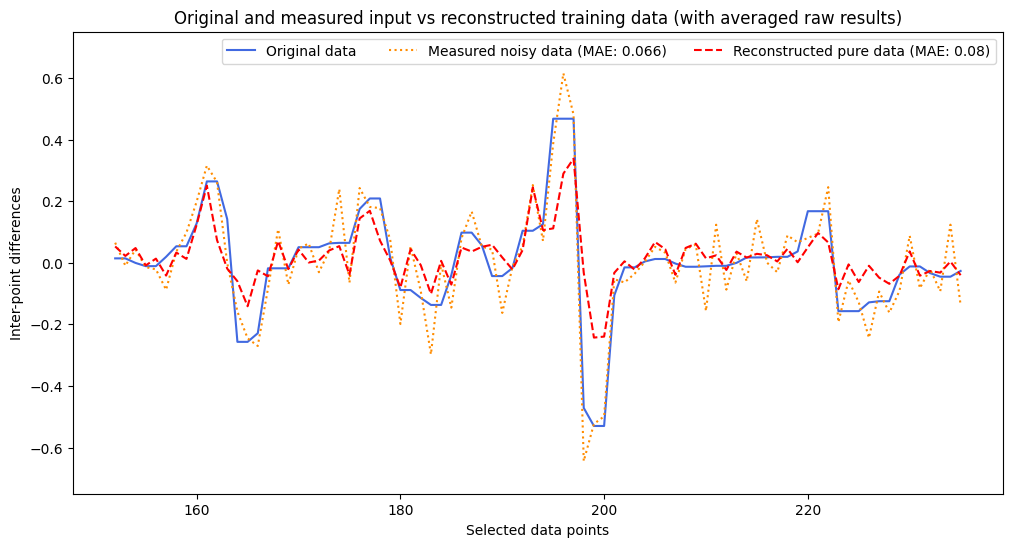

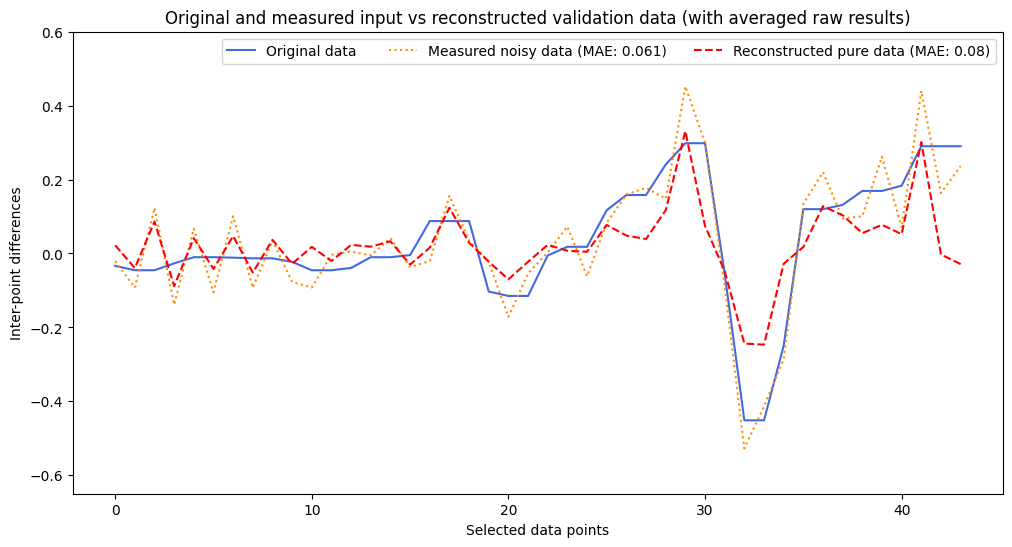



Plots saved in beer_qiskit_v5/figures/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_2000/winds_intxxx_org_bw.eps



In [42]:
# Plot all raw results
in_org_train_seq, in_meas_train_seq, out_recons_train_seq = qae_winds_integ(in_org_train_set, in_meas_train_set, out_reconstr_train_set)
qae_seq_plot(in_org_train_seq, in_meas_train_seq, out_recons_train_seq, title=f'Original and measured input vs reconstructed training data (with averaged raw results)',
             labels=['Original data', 'Measured noisy data', 'Reconstructed pure data'],
             label_suffix=[f'', f'(MAE: {np.round(mae_inorg_train_incalc, 3)})', f'(MAE: {np.round(mae_inorg_train_outrec, 3)})'], ylim=(-0.75,0.75),
             # save_plot=f'{FIGURES_PATH}/{TRAIN_PREF}_{epochs}/winds_inttra_org_bw.eps',
             line_styles=['solid', 'dotted', 'dashed'], marker_line_style='None',
             #line_cols=['black', 'gray', 'black']
            )

in_org_valid_seq, in_meas_valid_seq, out_recons_valid_seq = qae_winds_integ(in_org_valid_set, in_meas_valid_set, out_reconstr_valid_set)
qae_seq_plot(in_org_valid_seq, in_meas_valid_seq, out_recons_valid_seq, title=f'Original and measured input vs reconstructed validation data (with averaged raw results)',
             labels=['Original data', 'Measured noisy data', 'Reconstructed pure data'],
             label_suffix=[f'', f'(MAE: {np.round(mae_inorg_valid_incalc, 3)})', f'(MAE: {np.round(mae_inorg_valid_outrec, 3)})'], ylim=(-0.65,0.6),
             # save_plot=f'{FIGURES_PATH}/{TRAIN_PREF}_{epochs}/winds_intval_org_bw.eps',
             line_styles=['solid', 'dotted', 'dashed'], marker_line_style='None',
             # line_cols=['black', 'gray', 'black']
            )

print(f'Plots saved in {FIGURES_PATH}/{TRAIN_PREF}_{epochs}/winds_intxxx_org_bw.eps\n')

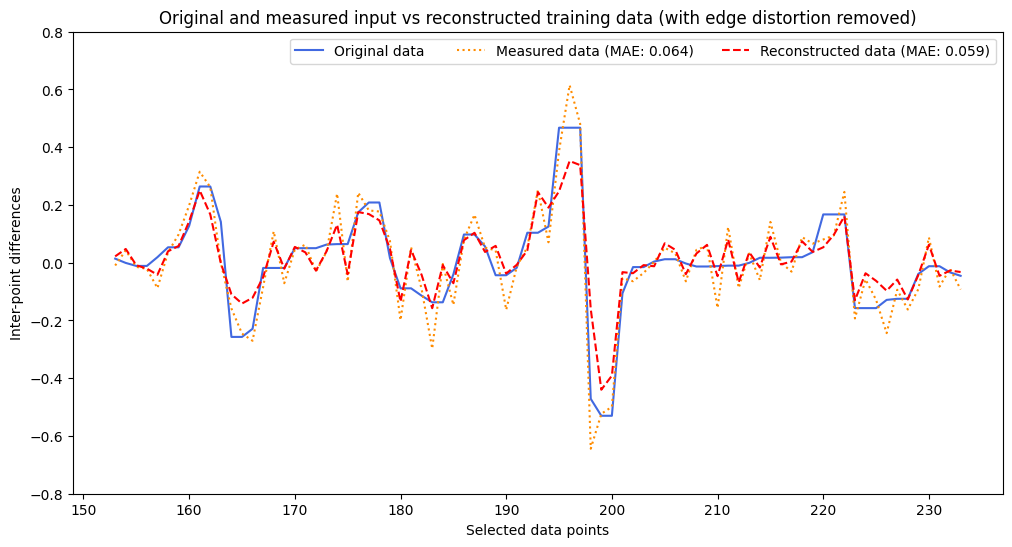

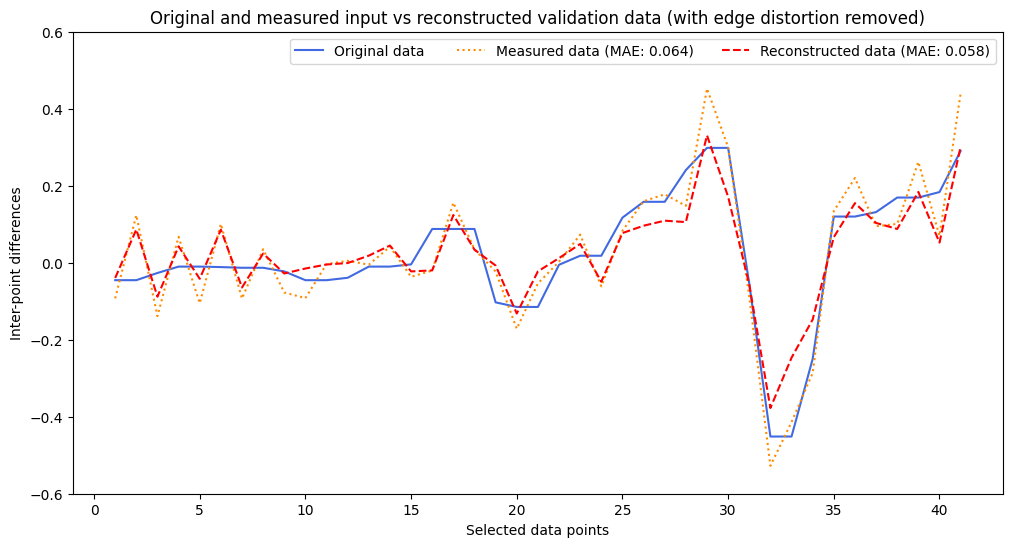



Plots saved in beer_qiskit_v5/figures/beer_xdf_2_n160_w8_ws4_z0.03_zr1_reps2_aw3_sca_lat7_2000/winds_intxxx_adj_bw.eps



In [43]:
# Plot all results with distortion trimming
in_org_adj_train_seq, in_meas_adj_train_seq, out_recons_adj_train_seq = qae_winds_integ(in_org_train_set, in_meas_train_set, out_reconstr_train_set, trim_left, trim_right)
qae_seq_plot(in_org_adj_train_seq, in_meas_adj_train_seq, out_recons_adj_train_seq, title=f'Original and measured input vs reconstructed training data (with edge distortion removed)',
             label_suffix=[f'', f'(MAE: {np.round(mae_adj_inorg_train_incalc, 3)})', f'(MAE: {np.round(mae_adj_inorg_train_outrec, 3)})'], ylim=(-0.8, 0.8),
             # save_plot=f'{FIGURES_PATH}/{TRAIN_PREF}_{epochs}/winds_inttra_adj_bw.eps',
             line_styles=['solid', 'dotted', 'dashed'], marker_line_style='None',
             # line_cols=['black', 'gray', 'black']
            )

in_org_adj_valid_seq, in_meas_adj_valid_seq, out_recons_adj_valid_seq = qae_winds_integ(in_org_valid_set, in_meas_valid_set, out_reconstr_valid_set, trim_left, trim_right)
qae_seq_plot(in_org_adj_valid_seq, in_meas_adj_valid_seq, out_recons_adj_valid_seq, title=f'Original and measured input vs reconstructed validation data (with edge distortion removed)',
             label_suffix=[f'', f'(MAE: {np.round(mae_adj_inorg_valid_incalc, 3)})', f'(MAE: {np.round(mae_adj_inorg_valid_outrec, 3)})'], ylim=(-0.6, 0.6),
             # save_plot=f'{FIGURES_PATH}/{TRAIN_PREF}_{epochs}/winds_intval_adj_bw.eps',
             line_styles=['solid', 'dotted', 'dashed'], marker_line_style='None',
             # line_cols=['black', 'gray', 'black']
            )

print(f'Plots saved in {FIGURES_PATH}/{TRAIN_PREF}_{epochs}/winds_intxxx_adj_bw.eps\n')

## Software in use

In [44]:
!pip list | grep -E 'qiskit|torch'

qiskit                        0.45.2
qiskit-aer-gpu                0.13.2
qiskit-algorithms             0.2.2
qiskit-dynamics               0.4.3
qiskit-finance                0.4.0
qiskit-ibm-provider           0.6.3
qiskit-ibm-runtime            0.11.3
qiskit-ibmq-provider          0.20.2
qiskit-machine-learning       0.7.1
qiskit-nature                 0.7.1
qiskit-optimization           0.6.0
qiskit-qasm3-import           0.4.1
qiskit-sphinx-theme           1.12.1
qiskit-terra                  0.45.2
torch                         2.1.0
torchaudio                    2.1.0
torchsummary                  1.5.1
torchvision                   0.16.0
torchviz                      0.0.2
